In [1]:
import matplotlib.pyplot as plt
#from pyclustree import clustree
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
import scimap as sm
import seaborn as sns
import os
import re
from pathlib import Path

Running SCIMAP  2.3.5


/home/iganiemi/anaconda3/envs/cycif_general/lib/python3.10/site-packages/mpl_scatter_density/__init__.py:4: UserWarning:

pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.

/home/iganiemi/anaconda3/envs/cycif_general/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html



In [ ]:
# INPUT
# 1. tribus output per each sample
# 2. manually gated cells with True/False values for all the gates which apply (exported 'obs' from h5ad object), combined for all the samples 

# OUTPUT
# 1. csv file combined for all the samples (as in input) with additional column for Tribus label and combined final label 

In [2]:
# set up paths
pdrive_mount_dir = "/home/ad/P-drive/h30492/"
#pdrive_mount_dir = "/run/user/1001/gvfs/smb-share:server=group3.ad.helsinki.fi,share=h30492/"

tribus_output_dir = os.path.join(pdrive_mount_dir, "farkkilab2/9_EyeMT/Data_analysis/cycif_processing/phenotyping/tribus_multiple_runs_test/tribus_output_single_best_b3")
tribus_output_list = [os.path.join(tribus_output_dir, f) for f in os.listdir(tribus_output_dir) if os.path.isfile(os.path.join(tribus_output_dir, f))]
tribus_output_list = [i for i in tribus_output_list if '_tribus_annotation' in i]

manual_gating_path = os.path.join(pdrive_mount_dir, "farkkilab2/7_TLS/Data/Exp_4/cell-phenotyping/20251601_gated_cells_all_gates.csv")

output_manual_tribus_labels_path = os.path.join(pdrive_mount_dir, "farkkilab2/9_EyeMT/Data_analysis/cycif_processing/phenotyping/tribus_multiple_runs_test/20251601_gated_cells_all_gates_tribus_final_labels.csv")
output_comparison_plots_dir = os.path.join(tribus_output_dir, 'hmap_tribus_vs_refined')

if not os.path.exists(output_comparison_plots_dir):
    os.makedirs(output_comparison_plots_dir)

In [4]:
# to include in  manual_gating_label
manual_gates_markers_list = ['PanCK', 'Vimentin', 'aSMA', 'CD11c', 'Iba1', 'HLA-DPB2', 'CD20', 'CD4', 'CD8a']

In [5]:
# manual gating marker names
# ['Unnamed: 0', 'CellID', 'imageid', 'X_centroid', 'Y_centroid', 'BCL6',
#        'CD138', 'Tcf1', 'FOXP3', 'PD1', 'CD21', 'Ki-67', 'CD20', 'Vimentin',
#        'CD4', 'CD11c', 'CD8a', 'HEV', 'PanCK', 'CD31', 'Iba1', 'CD3D', 'IgD',

# add given label if cell is positive in a given gate
def label_cell_all_labs(row, markers):
    lab = ''
    for marker in markers:
        if row[marker] == True and not np.isnan(row[marker]):
            lab = lab + '_' + marker
    if lab == '':
        lab = 'Undefined'
    else:
        lab = lab.removeprefix('_')
    return(lab)

# add information if immune cells have been gated within stroma or tumor
def label_tribus(row):
    if row['Stroma'] == 'Stroma_Immune':
        lab = 'Stroma_' + row['final_label']
    elif row['Tumor'] == 'Tumor_Immune':
        lab = 'Tumor_' + row['final_label']
    else:
        lab = row['final_label']

    if any(x in lab for x in ['other', 'undefined']):
        return 'Undefined'
    else:
        return lab

# merge manual gating imageid with tribus sample names
def samplename_to_imageid(tribus_output_path):
    if 'S026_iOme1' in tribus_output_path:
        imageid = 'S026_1'
    elif 'S026_iOme2' in tribus_output_path:
        imageid = 'S026_2'
    else:
        imageid = Path(tribus_output_path).stem.removeprefix('7-').split('_')[0]
    return(imageid)

In [6]:
# Read manual gated sample and simplify column names
sample_data_all = pd.read_csv(manual_gating_path)  

sample_data_all.columns = sample_data_all.columns.str.removesuffix('_normalized_positive')
sample_data_all.columns = sample_data_all.columns.str.removesuffix('_filt_norm_positive')

# make labels column from manual gates
# sample_data_all['manual_gating_labels'] = sample_data_all.apply(label_cell_all_labs, axis=1, markers = manual_gates_markers_list)

print(sample_data_all.shape)
print(sample_data_all.columns)
#print(sample_data_all.manual_gating_labels.value_counts())

(27907838, 26)
Index(['Unnamed: 0', 'CellID', 'imageid', 'X_centroid', 'Y_centroid', 'BCL6',
       'CD138', 'Tcf1', 'FOXP3', 'PD1', 'CD21', 'Ki-67', 'CD20', 'Vimentin',
       'CD4', 'CD11c', 'CD8a', 'HEV', 'PanCK', 'CD31', 'Iba1', 'CD3D', 'IgD',
       'aSMA', 'HLA-DPB2', 'HLA-A'],
      dtype='object')


In [7]:
# load and merge all tribus files
tribus_output_df_list = []

for tribus_output_pt_path in tribus_output_list:
    tribus_pt = pd.read_csv(tribus_output_pt_path, index_col=None, header=0)
    tribus_pt['imageid'] = samplename_to_imageid(tribus_output_pt_path)
    tribus_pt['Sample'] = '_'.join(Path(tribus_output_pt_path).stem.removeprefix('7-').split('_')[0:2]) 
    tribus_output_df_list.append(tribus_pt)

tribus_output_df_all = pd.concat(tribus_output_df_list, axis=0, ignore_index=True)

# # add initial global label to final label and merge undefined
tribus_output_df_all['final_label_tribus'] = tribus_output_df_all.apply(label_tribus, axis=1)

# print(tribus_output_df_all.head(15))

In [8]:
# merge manual gated cells and tribus labels by imageid and CellID
sample_data_all = pd.merge(sample_data_all, tribus_output_df_all.loc[:, ['imageid', 'Sample', 'CellID', 'final_label_tribus']] ,  how='left', on=['imageid','CellID'])

# add category name if not in tribus (eg sample has not been computed)
sample_data_all['final_label_tribus'] = sample_data_all['final_label_tribus'].fillna('notintribus')

# remove whitespaces
sample_data_all['final_label_tribus'] = sample_data_all['final_label_tribus'].astype(str).str.strip()

In [9]:
# patients which not in tribus
print(set(sample_data_all.imageid).difference(set(tribus_output_df_all.imageid)))

print(sample_data_all.final_label_tribus.value_counts())

{'S083'}
final_label_tribus
Stroma_Stroma                6380358
Tumor_Tumor                  5621852
Immune_CD4_Tcells            2017217
Immune_Dcs                   1865224
Immune_Macrophages           1849114
Immune_CD8_Tcells            1770236
Stroma_Immune_CD4_Tcells     1612636
notintribus                  1381230
Stroma_Immune_Macrophages    1328301
Stroma_Immune_Dcs             771403
Stroma_Immune_CD8_Tcells      768119
Tumor_Immune_CD4_Tcells       665027
Tumor_Immune_Macrophages      591667
Tumor_Immune_Dcs              489442
Tumor_Immune_CD8_Tcells       467289
Undefined                     328723
Name: count, dtype: int64


In [10]:
# refine labels 

# TODO make 1 function out of spagetti code

# define the "failed marker" conditions where tribus labeled a cell with negative gate for its marker
failed_check = (
    ((sample_data_all['final_label_tribus'].str.contains('CD4', na=False)) & (sample_data_all['CD4'] == False)) |
    ((sample_data_all['final_label_tribus'].str.contains('CD8', na=False)) & (sample_data_all['CD8a'] == False)) |
    ((sample_data_all['final_label_tribus'].str.contains('Macrophage', na=False)) & (sample_data_all['Iba1'] == False)) |
    ((sample_data_all['final_label_tribus'].str.contains('Dcs', na=False)) & (sample_data_all['CD11c'] == False))
)

# define fallback logic function 
def get_fallback_label(label):
    if 'Stroma' in str(label):
        return 'Stroma_Stroma'
    elif 'Tumor' in str(label):
        return 'Tumor_Tumor'
    else:
        return 'Stroma_Stroma'

# create consensus: when "failed marker" condition is met and tribus labeled cell within Tumor/Stroma, change to Tumor/Stroma 
sample_data_all['consensus_label'] = np.where(
    failed_check,
    sample_data_all['final_label_tribus'].apply(get_fallback_label),
    sample_data_all['final_label_tribus']
)

# apply additional condition: if cell is labelled by tribus inside Tumor (Tumor_Tumor) (or was moved there in the previous step) and is Positive in CD8 gate:
# change to Tumor_Immune_CD8_Tcells
tumor_cd8_mask = (sample_data_all['consensus_label'] == 'Tumor_Tumor') & (sample_data_all['CD8a'] == True)
sample_data_all['consensus_label'] = np.where(tumor_cd8_mask, 'Tumor_Immune_CD8_Tcells', sample_data_all['consensus_label'])

# create simplified column with cleaned labels and strip spaces
sample_data_all['consensus_label'] = sample_data_all['consensus_label'].astype(str).str.strip()

def simplify_label(label):
    label = str(label).strip()
    # Match pattern: find things like CD8_Tcells or CD4_Tcells at the end
    match = re.search(r'([A-Za-z0-9]+_Tcells)$', label)
    if match:
        return match.group(1)
    # Fallback: if not a Tcell, just take the last part after the last underscore
    return label.split('_')[-1]

sample_data_all['consensus_label_clean'] = sample_data_all['consensus_label'].apply(simplify_label)

# convert to categories
sample_data_all['consensus_label'] = sample_data_all['consensus_label'].astype('category')
sample_data_all['consensus_label_clean'] = sample_data_all['consensus_label_clean'].astype('category')

In [11]:
# define hierarchy for relabelling for additional cell types

def relabel_with_hierarchy(row):
    label = str(row['consensus_label_clean']).strip()
    
    # Define the specific populations to check
    target_cells = ['Tumor', 'Stroma', 'Macrophages', 'DCs', 'CD4_Tcells', 'CD8_Tcells']
    
    if label in target_cells:
        # 1. First check: CD31 (Highest Priority)
        if row['CD31'] == True:
            return 'CD31+_Endothelial'
        
        # 2. Second check: HEV
        if row['HEV'] == True:
            return 'HEV+_Endothelial'
            
        # 3. Third check: CD20
        if row['CD20'] == True:
            if label == 'CD8_Tcells':
                return 'CD8_Tcells'
            elif label == 'CD4_Tcells':
                return 'Bcells'
            else:
                return 'Bcells' # For Tumor, Stroma, Macrophages, DCs
                
    return label

# Apply the hierarchical relabeling
sample_data_all['consensus_label_clean_all_ct'] = sample_data_all.apply(relabel_with_hierarchy, axis=1)
sample_data_all['consensus_label_clean_all_ct'] = sample_data_all['consensus_label_clean_all_ct'].astype('category')

label_map = {
    "CD31+": "CD31_Endothelial",
    "HEV+": "HEV_Endothelial",
    "Dcs": "DCs",
    "B cells": "B_cells"
}

# replace some labels
sample_data_all["consensus_label_clean_all_ct"] = sample_data_all["consensus_label_clean_all_ct"].replace(label_map)
sample_data_all["consensus_label_clean"] = sample_data_all["consensus_label_clean"].replace(label_map)

/tmp/ipykernel_151588/3207204598.py:41: FutureWarning:

The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.

/tmp/ipykernel_151588/3207204598.py:42: FutureWarning:

The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.



In [12]:
print(sample_data_all.consensus_label_clean.value_counts())
print(sample_data_all.consensus_label_clean_all_ct.value_counts())

consensus_label_clean
Stroma         10724412
Tumor           6509265
Macrophages     2708152
DCs             2697209
CD8_Tcells      2058094
CD4_Tcells      1500753
notintribus     1381230
Undefined        328723
Name: count, dtype: int64
consensus_label_clean_all_ct
Stroma               9124505
Tumor                6211252
DCs                  2697209
Macrophages          2287169
CD31+_Endothelial    1989604
CD8_Tcells           1916197
notintribus          1381230
CD4_Tcells           1190952
Bcells                587773
Undefined             328723
HEV+_Endothelial      193224
Name: count, dtype: int64


In [13]:
# save
sample_data_all.to_csv(output_manual_tribus_labels_path)

In [14]:
def simplify_label(label):
    label = str(label).strip()
    # Match pattern: find things like CD8_Tcells or CD4_Tcells at the end
    match = re.search(r'([A-Za-z0-9]+_Tcells)$', label)
    if match:
        return match.group(1)
    # Fallback: if not a Tcell, just take the last part after the last underscore
    return label.split('_')[-1]

In [16]:
# hmap showing how many cells are labeled the same across manual gating vs tribus categories
def make_crosslabel_hmap(sample_data, label1_colname, label2_colname, outp_dir, pt_name, logic_name): 

    # Crosstab of counts manual to tribus
    # intersection_counts = pd.crosstab(
    #     sample_data.obs["phenotype_tribus_homogenized"],
    #     sample_data.obs["final_label_tribus"]
    # )

    # Crosstab of counts tribus to manual
    intersection_counts = pd.crosstab(
        sample_data[label1_colname],
        sample_data[label2_colname]
    )
    
    # Normalize by total (grand total %)
    intersection_pct_total = intersection_counts.div(intersection_counts.sum().sum()) * 100
    
    # Normalize by row (within each phenotype %)
    intersection_pct_row = intersection_counts.div(intersection_counts.sum(axis=1), axis=0) * 100
    
    # Plot: row-wise %
    plt.figure(figsize=(10,6))
    sns.heatmap(intersection_pct_row, annot=True, fmt=".1f", cmap="magma")
    plt.title("Intersection (% within each phenotype)")
    plt.xlabel(label2_colname)
    plt.ylabel(label1_colname)
    plt.tight_layout()
    #plt.show()
    plt.savefig(os.path.join(outp_dir, pt_name + '_heatmap_' + logic_name + '.png'))

    return None

In [6]:
# read once again to plot the hmap
sample_data_all = pd.read_csv(output_manual_tribus_labels_path)

print(sample_data_all.columns.values)

['Unnamed: 0.1' 'Unnamed: 0' 'CellID' 'imageid' 'X_centroid' 'Y_centroid'
 'BCL6' 'CD138' 'Tcf1' 'FOXP3' 'PD1' 'CD21' 'Ki-67' 'CD20' 'Vimentin'
 'CD4' 'CD11c' 'CD8a' 'HEV' 'PanCK' 'CD31' 'Iba1' 'CD3D' 'IgD' 'aSMA'
 'HLA-DPB2' 'HLA-A' 'final_label_tribus' 'consensus_label'
 'consensus_label_clean' 'consensus_label_clean_all_ct']


In [15]:
sample_data_all['final_label_tribus'] = sample_data_all['final_label_tribus'].apply(simplify_label)
sample_data_all['final_label_tribus'] = sample_data_all['final_label_tribus'].astype('category')

print(sample_data_all.final_label_tribus.value_counts())
print(sample_data_all.consensus_label_clean.value_counts())
print(sample_data_all.consensus_label_clean_all_ct.value_counts())

final_label_tribus
Stroma         6380358
Tumor          5621852
CD4_Tcells     4294880
Macrophages    3769082
Dcs            3126069
CD8_Tcells     3005644
tribus         1381230
Undefined       328723
Name: count, dtype: int64
consensus_label_clean
Stroma         10724412
Tumor           6509265
Macrophages     2708152
DCs             2697209
CD8_Tcells      2058094
CD4_Tcells      1500753
tribus          1381230
Undefined        328723
Name: count, dtype: int64
consensus_label_clean_all_ct
Stroma               9124505
Tumor                6211252
DCs                  2697209
Macrophages          2287169
CD31+_Endothelial    1989604
CD8_Tcells           1916197
tribus               1381230
CD4_Tcells           1190952
Bcells                587773
Undefined             328723
HEV+_Endothelial      193224
Name: count, dtype: int64


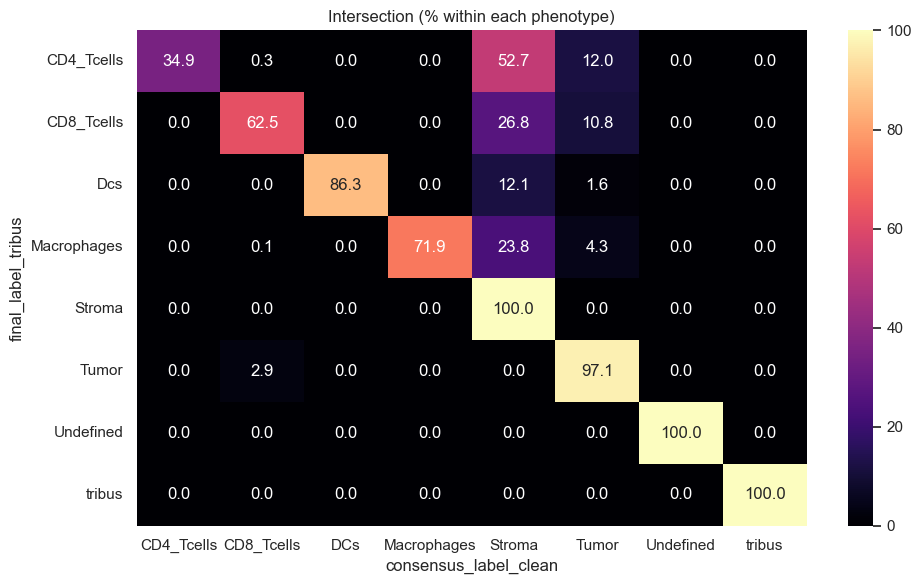

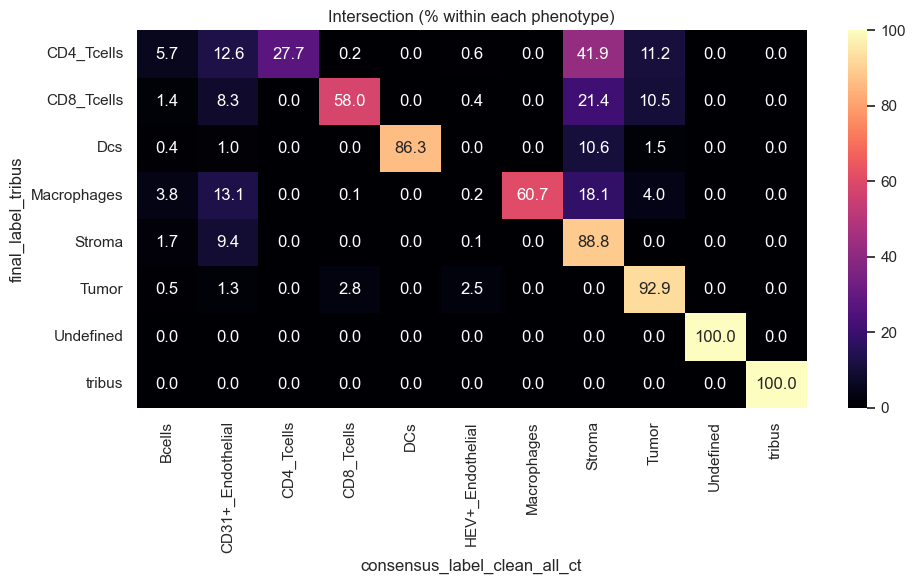

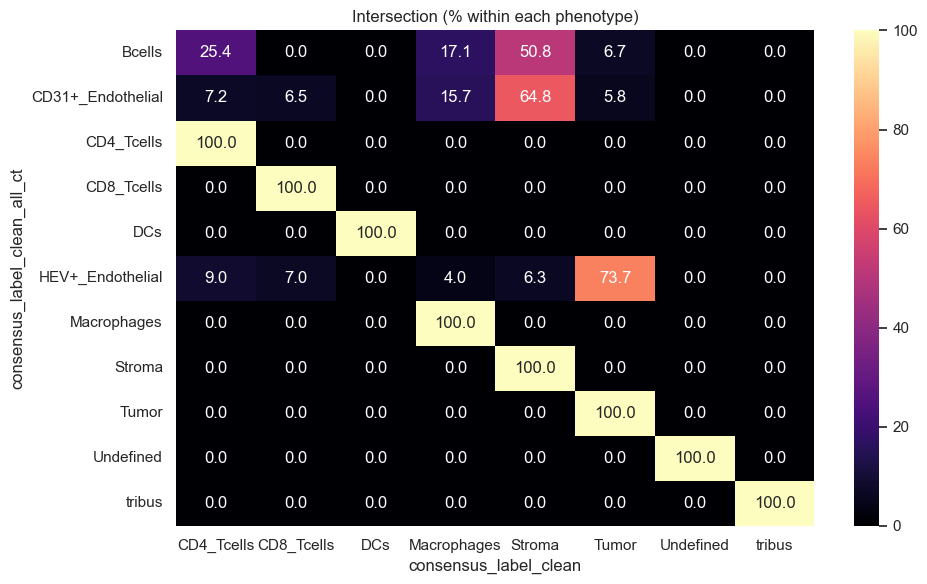

In [17]:
make_crosslabel_hmap(sample_data_all, 'final_label_tribus', 'consensus_label_clean', output_comparison_plots_dir, 'tribus_vs_refined', '')
make_crosslabel_hmap(sample_data_all, 'final_label_tribus', 'consensus_label_clean_all_ct', output_comparison_plots_dir, 'tribus_vs_refined_all_ct', '')
make_crosslabel_hmap(sample_data_all, 'consensus_label_clean_all_ct', 'consensus_label_clean',  output_comparison_plots_dir, 'refined_vs_refined_all_ct', '')